<a href="https://colab.research.google.com/github/lightcode01-oss/IYB_INTERNSHIP/blob/main/Day_08_Baseline_Classification_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAY 08 — Baseline Classification Model

## YBI Foundation — Python, AI & Data Science Internship

### Objective

The objective of Day 08 is to train the first baseline machine learning
classification model for the Student Performance Prediction project.

### Today's Work

- Load the dataset independently.
- Recreate the project target.
- Prevent target leakage.
- Split the dataset into training and testing sets.
- Recreate the preprocessing pipeline.
- Train a baseline Logistic Regression classifier.
- Generate predictions.
- Evaluate the baseline model.
- Analyze the confusion matrix.
- Calculate classification metrics.
- Record the baseline results.

No hyperparameter tuning will be performed today.

In [1]:
!pip -q install ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
student_performance = fetch_ucirepo(id=320)

X = student_performance.data.features
y_original = student_performance.data.targets

df = X.copy()
df["G3"] = y_original["G3"]

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (649, 31)


In [3]:
def performance_category(grade):
    if grade < 10:
        return "Low"
    elif grade < 15:
        return "Medium"
    else:
        return "High"

df["performance_category"] = df["G3"].apply(
    performance_category
)

print(df["performance_category"].value_counts())

performance_category
Medium    418
High      131
Low       100
Name: count, dtype: int64


In [4]:
target = "performance_category"

X = df.drop(columns=[target])
y = df[target]

print("Original feature count:", X.shape[1])
print("Target classes:", y.unique())

Original feature count: 31
Target classes: ['Medium' 'High' 'Low']


In [5]:
X_model = X.drop(columns=["G3"])

print("G3 present in model features:", "G3" in X_model.columns)
print("Final model feature count:", X_model.shape[1])

G3 present in model features: False
Final model feature count: 30


In [6]:
numerical_features = [
    "age",
    "absences"
]

ordinal_features = [
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health"
]

binary_features = [
    "school",
    "sex",
    "address",
    "famsize",
    "Pstatus",
    "schoolsup",
    "famsup",
    "paid",
    "activities",
    "nursery",
    "higher",
    "internet",
    "romantic"
]

nominal_features = [
    "Mjob",
    "Fjob",
    "reason",
    "guardian"
]

categorical_features = (
    binary_features +
    nominal_features
)

print("Numerical:", len(numerical_features))
print("Ordinal:", len(ordinal_features))
print("Categorical:", len(categorical_features))

Numerical: 2
Ordinal: 11
Categorical: 17


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 519
Testing samples: 130


In [8]:
categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_encoder,
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features + ordinal_features
        )
    ],
    remainder="drop"
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [9]:
baseline_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

print("Baseline Logistic Regression model created.")

Baseline Logistic Regression model created.


In [10]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", baseline_model)
    ]
)

print("Complete baseline pipeline created.")

Complete baseline pipeline created.


In [11]:
baseline_pipeline.fit(
    X_train,
    y_train
)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [12]:
y_pred = baseline_pipeline.predict(X_test)

print("Predictions generated successfully.")

print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions generated successfully.

First 20 predictions:
['Medium' 'Medium' 'Medium' 'Low' 'Low' 'Medium' 'Medium' 'High' 'Medium'
 'Low' 'Medium' 'Medium' 'Medium' 'Medium' 'Medium' 'Medium' 'Medium'
 'Medium' 'Medium' 'Medium']


In [13]:
prediction_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

prediction_comparison.head(20)

,Actual,Predicted
0,Medium,Medium
1,Low,Medium
2,Medium,Medium
3,Low,Low
4,Medium,Low
5,Medium,Medium
6,High,Medium
7,Medium,High
8,Medium,Medium
9,Low,Low


In [14]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Baseline Accuracy:", round(accuracy, 4))
print("Baseline Accuracy (%):", round(accuracy * 100, 2))

Baseline Accuracy: 0.6692
Baseline Accuracy (%): 66.92


In [15]:
precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("Macro Precision:", round(precision, 4))

Macro Precision: 0.5999


In [16]:
recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("Macro Recall:", round(recall, 4))

Macro Recall: 0.5076


In [17]:
f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("Macro F1 Score:", round(f1, 4))

Macro F1 Score: 0.5106


In [18]:
baseline_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Macro Precision": [precision],
    "Macro Recall": [recall],
    "Macro F1": [f1]
})

baseline_results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.669231,0.599889,0.507631,0.510613


In [19]:
print(
    classification_report(
        y_test,
        y_pred,
        labels=["Low", "Medium", "High"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

         Low       0.53      0.50      0.51        20
      Medium       0.70      0.87      0.78        84
        High       0.57      0.15      0.24        26

    accuracy                           0.67       130
   macro avg       0.60      0.51      0.51       130
weighted avg       0.65      0.67      0.63       130



In [20]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Low", "Medium", "High"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  9  1]
 [ 9 73  2]
 [ 0 22  4]]


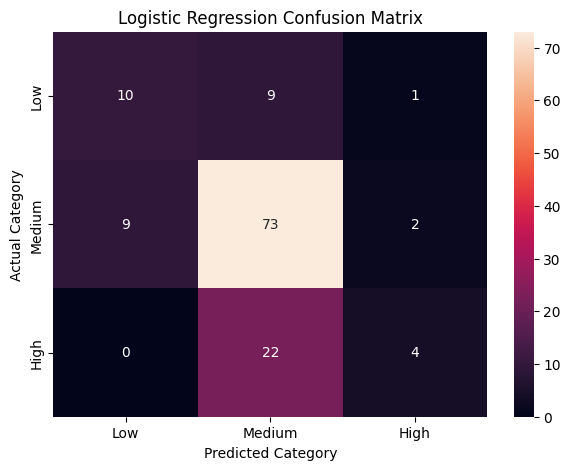

In [21]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.show()

In [22]:
print("Actual class distribution:")
print(y_test.value_counts())

print("\nPredicted class distribution:")
print(pd.Series(y_pred).value_counts())

Actual class distribution:
performance_category
Medium    84
High      26
Low       20
Name: count, dtype: int64

Predicted class distribution:
Medium    104
Low        19
High        7
Name: count, dtype: int64


In [23]:
y_train_pred = baseline_pipeline.predict(X_train)

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

test_accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Training Accuracy:", round(train_accuracy, 4))
print("Testing Accuracy:", round(test_accuracy, 4))

Training Accuracy: 0.6956
Testing Accuracy: 0.6692


In [24]:
accuracy_gap = train_accuracy - test_accuracy

print("Training Accuracy:", round(train_accuracy, 4))
print("Testing Accuracy:", round(test_accuracy, 4))
print("Accuracy Gap:", round(accuracy_gap, 4))

Training Accuracy: 0.6956
Testing Accuracy: 0.6692
Accuracy Gap: 0.0263


In [25]:
probabilities = baseline_pipeline.predict_proba(X_test)

print("Probability matrix shape:", probabilities.shape)

print("\nFirst 5 probability predictions:")
print(probabilities[:5])

Probability matrix shape: (130, 3)

First 5 probability predictions:
[[0.09809452 0.16879802 0.73310746]
 [0.04809459 0.33546111 0.6164443 ]
 [0.20821548 0.23872591 0.55305861]
 [0.01059121 0.5065938  0.48281499]
 [0.11678964 0.57946454 0.30374582]]


In [26]:
classes = baseline_pipeline.named_steps[
    "classifier"
].classes_

print("Class order:")
print(classes)

Class order:
['High' 'Low' 'Medium']


In [27]:
prediction_confidence = probabilities.max(axis=1)

confidence_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Confidence": prediction_confidence
})

confidence_df.head(10)

,Actual,Predicted,Confidence
0,Medium,Medium,0.733107
1,Low,Medium,0.616444
2,Medium,Medium,0.553059
3,Low,Low,0.506594
4,Medium,Low,0.579465
5,Medium,Medium,0.908462
6,High,Medium,0.864830
7,Medium,High,0.638930
8,Medium,Medium,0.887150
9,Low,Low,0.745771


In [28]:
confidence_df.sort_values(
    by="Confidence",
    ascending=False
).head(10)

,Actual,Predicted,Confidence
115,Low,Medium,0.979046
86,Low,Medium,0.967561
59,Low,Low,0.962383
17,Medium,Medium,0.940867
48,Medium,Medium,0.929576
18,Medium,Medium,0.929052
62,Medium,Medium,0.923755
102,Medium,Medium,0.918758
19,Medium,Medium,0.909669
5,Medium,Medium,0.908462


In [29]:
confidence_df.sort_values(
    by="Confidence",
    ascending=True
).head(10)

,Actual,Predicted,Confidence
87,Medium,Medium,0.391383
54,High,High,0.403568
44,Medium,Medium,0.463530
31,Medium,Low,0.477347
16,Medium,Medium,0.485605
114,Medium,Low,0.497437
97,High,Medium,0.497772
28,Medium,Medium,0.500781
13,Medium,Medium,0.504479
69,Low,Low,0.505015


In [30]:
baseline_results.to_csv(
    "day_08_baseline_results.csv",
    index=False
)

print("Baseline results saved successfully.")

Baseline results saved successfully.


In [31]:
print("=" * 60)
print("DAY 08 BASELINE MODEL CHECK")
print("=" * 60)

print("Model:", "Logistic Regression")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining Accuracy:",
      round(train_accuracy, 4))

print("Testing Accuracy:",
      round(test_accuracy, 4))

print("Macro Precision:",
      round(precision, 4))

print("Macro Recall:",
      round(recall, 4))

print("Macro F1:",
      round(f1, 4))

print("\nG3 leakage removed:",
      "G3" not in X_model.columns)

print("\nBaseline model training completed successfully.")

DAY 08 BASELINE MODEL CHECK
Model: Logistic Regression
Training samples: 519
Testing samples: 130

Training Accuracy: 0.6956
Testing Accuracy: 0.6692
Macro Precision: 0.5999
Macro Recall: 0.5076
Macro F1: 0.5106

G3 leakage removed: True

Baseline model training completed successfully.


# Day 08 — Baseline Model Findings

## Baseline Model

A Logistic Regression classifier was selected as the first baseline model for
the Student Performance classification problem.

The model was chosen as a simple and interpretable starting point before
testing more complex algorithms.

## Preprocessing

The preprocessing pipeline created on Day 07 was integrated directly with
the classifier.

Categorical variables were one-hot encoded while numerical and ordinal
features were retained in numerical form.

## Data Leakage Prevention

The `G3` feature was removed before model training because the project target
`performance_category` is directly derived from `G3`.

This prevents the baseline model from receiving direct information about the
target.

## Evaluation

The baseline model was evaluated using:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1 Score
- Classification Report
- Confusion Matrix

Macro averaging was used for precision, recall and F1 because the project
contains three performance classes.

## Training vs Testing

Training and testing accuracy were compared as an initial generalization
check.

This comparison is only a diagnostic and will not be used alone to determine
whether the model is overfitting.

## Prediction Confidence

The Logistic Regression model also produced class probabilities. These were
used to inspect the confidence associated with individual predictions.

## Conclusion

Day 08 established the first machine learning baseline for the project.

The baseline metrics will be retained and later compared with additional
classification algorithms.

No hyperparameter tuning was performed at this stage.

# DAY 08 DEVELOPMENT LOG

## Work Completed

- Created an independent Day 08 notebook.
- Loaded the Student Performance dataset.
- Recreated the project performance categories.
- Separated features and target.
- Removed `G3` to prevent target leakage.
- Recreated the preprocessing pipeline.
- Performed a stratified train-test split.
- Created a Logistic Regression classifier.
- Combined preprocessing and classification into one pipeline.
- Trained the baseline model.
- Generated predictions.
- Calculated accuracy.
- Calculated macro precision.
- Calculated macro recall.
- Calculated macro F1 score.
- Generated a classification report.
- Generated a confusion matrix.
- Visualized the confusion matrix.
- Compared training and testing accuracy.
- Generated class probability predictions.
- Examined prediction confidence.
- Saved the baseline metric results.

## Key Learning

A baseline model provides an initial reference point for evaluating future
machine learning models.

Using a complete preprocessing and model pipeline ensures that data
transformations are applied consistently.

## Important Project Decision

Logistic Regression will be treated as the baseline model.

Future algorithms will be evaluated using the same train-test split and
evaluation metrics so that the comparison remains consistent.

## Next Step

Day 09 will introduce another classification algorithm and compare its
performance with the Logistic Regression baseline.